In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/diabetic_cleaned.csv")

In [3]:
df.shape

(101766, 41)

In [4]:
df.info()
df.describe().T
df["Readmitted_30D"].value_counts(normalize=True) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   gender                    101766 non-null  object
 3   age                       101766 non-null  object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   num_lab_procedures        101766 non-null  int64 
 9   num_procedures            101766 non-null  int64 
 10  num_medications           101766 non-null  int64 
 11  number_outpatient         101766 non-null  int64 
 12  number_emergency          101766 non-null  int64 
 13  number_inpatient          101766 non-null  int64 
 14  numb

Readmitted_30D
0    88.840084
1    11.159916
Name: proportion, dtype: float64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [6]:
df["Readmitted_30D"].value_counts(normalize=True) * 100

Readmitted_30D
0    88.840084
1    11.159916
Name: proportion, dtype: float64

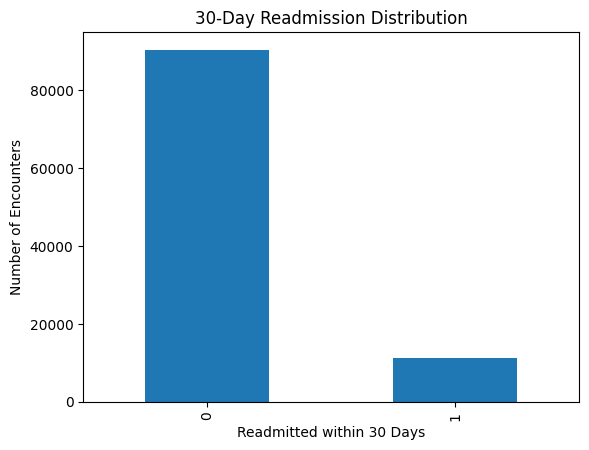

In [7]:
df["Readmitted_30D"].value_counts().plot(kind="bar")
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Encounters")
plt.show()

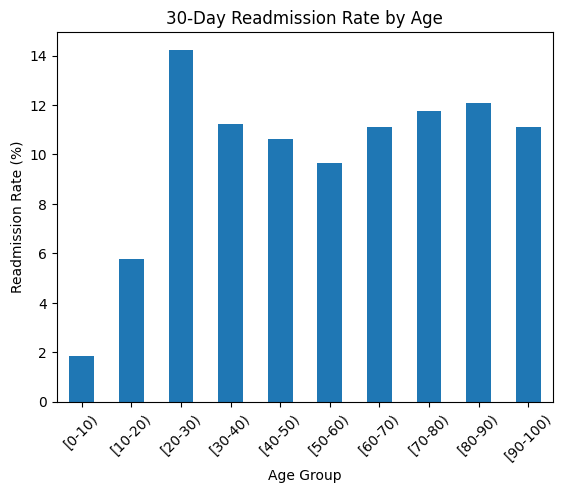

In [8]:
age_readmit = df.groupby("age")["Readmitted_30D"].mean() * 100

age_readmit.plot(kind="bar")
plt.title("30-Day Readmission Rate by Age")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.show()

# 2 . Prior inpatient visits


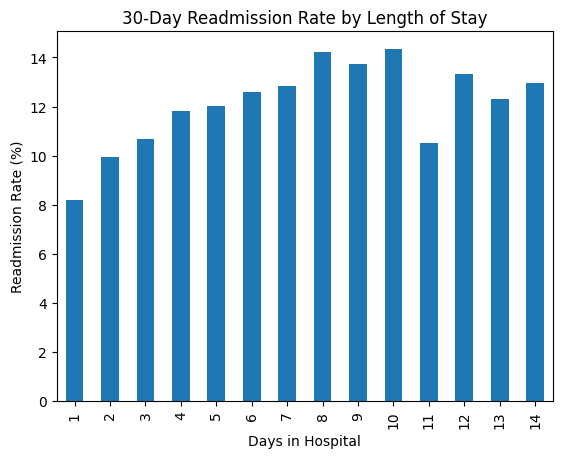

In [10]:
stay_readmit = df.groupby("time_in_hospital")["Readmitted_30D"].mean() * 100

stay_readmit.plot(kind="bar")
plt.title("30-Day Readmission Rate by Length of Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")
plt.show()

# 3. Number of medications 

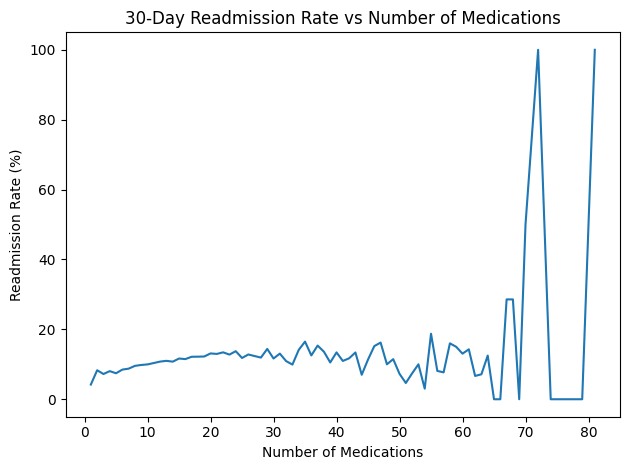

In [12]:
med_readmit = df.groupby("num_medications")["Readmitted_30D"].mean() * 100

med_readmit.plot()
plt.title("30-Day Readmission Rate vs Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.savefig("../visualizations/eda/readmission_by_medications.png")
plt.show()

# 4. Numeric correlation

In [13]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()["Readmitted_30D"].sort_values(ascending=False)
print(corr)

Readmitted_30D              1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
patient_nbr                 0.007893
admission_source_id         0.005820
encounter_id               -0.008519
admission_type_id          -0.011651
num_procedures             -0.012227
Name: Readmitted_30D, dtype: float64
